In [2]:
import seaborn as sns
import pandas as pd
df = sns.load_dataset('titanic')
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
df.shape

(891, 15)

In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.drop('embark_town', axis = 1 , inplace = True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,no,True


<Axes: xlabel='age', ylabel='Count'>

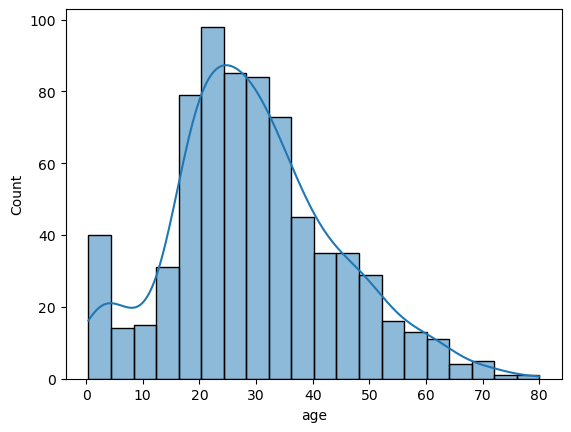

In [6]:
sns.histplot(df['age'] , kde = True)

In [7]:
df['age'] = df['age'].fillna(df['age'].mean())


In [8]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age             0
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
deck          688
alive           0
alone           0
dtype: int64

In [9]:
df.drop('deck' , axis = 1 , inplace = True)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


In [10]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [11]:
df.drop('sibsp' , axis = 1 , inplace = True)
df.drop('parch' , axis = 1 , inplace = True)
df.drop('fare' , axis = 1 , inplace = True)
df.drop('pclass' , axis = 1 , inplace = True)
df.head()

,survived,sex,age,embarked,class,who,adult_male,alive,alone
0,0,male,22.0,S,Third,man,True,no,False
1,1,female,38.0,C,First,woman,False,yes,False
2,1,female,26.0,S,Third,woman,False,yes,True
3,1,female,35.0,S,First,woman,False,yes,False
4,0,male,35.0,S,Third,man,True,no,True


<Axes: xlabel='sex', ylabel='count'>

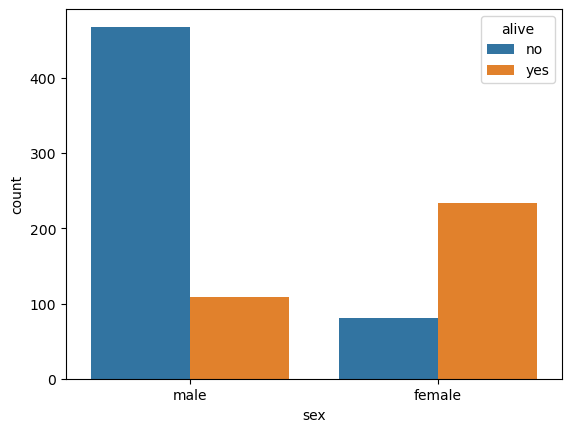

In [12]:
df.drop('survived' , axis = 1 , inplace = True)
sns.countplot( x = 'sex' , hue = 'alive' , data = df)

<Axes: xlabel='class', ylabel='count'>

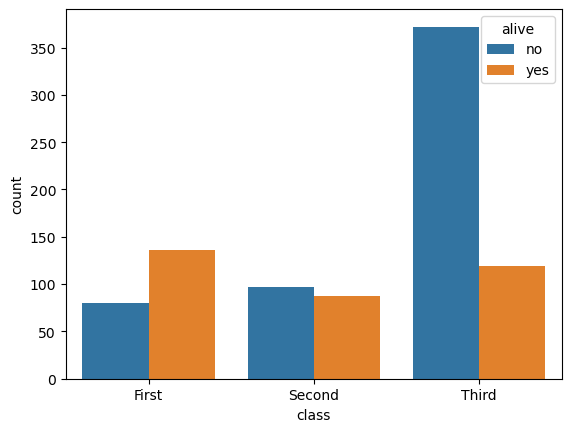

In [13]:
df.drop('who' , axis = 1 , inplace = True)
sns.countplot( x='class' , hue = 'alive' , data = df)

In [14]:
df['alive'] = df['alive'].map({'yes':1 , 'no':0})
df.groupby('sex')['alive'].mean()

sex
female    0.742038
male      0.188908
Name: alive, dtype: float64

In [15]:

df.groupby('class')['alive'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_13588\3721883764.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class')['alive'].mean()


class
First     0.629630
Second    0.472826
Third     0.242363
Name: alive, dtype: float64

<Axes: xlabel='class', ylabel='count'>

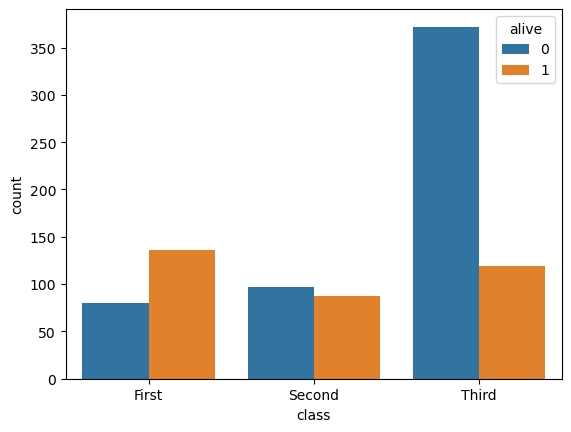

In [16]:
sns.countplot( x = 'class' , hue = 'alive' , data = df)

In [17]:

df['age'].max()

80.0

In [18]:
df['age'].min()

0.42

In [19]:

bins = [0,20,40,60,80]
labels = ['0-20' , '20-40' , '40-60' , '60-80']
df['age_group'] = pd.cut(df['age'] , bins = bins , labels = labels ,right = False)
df.head()


,sex,age,embarked,class,adult_male,alive,alone,age_group
0,male,22.0,S,Third,True,0,False,20-40
1,female,38.0,C,First,False,1,False,20-40
2,female,26.0,S,Third,False,1,True,20-40
3,female,35.0,S,First,False,1,False,20-40
4,male,35.0,S,Third,True,0,True,20-40


<Axes: xlabel='age_group', ylabel='count'>

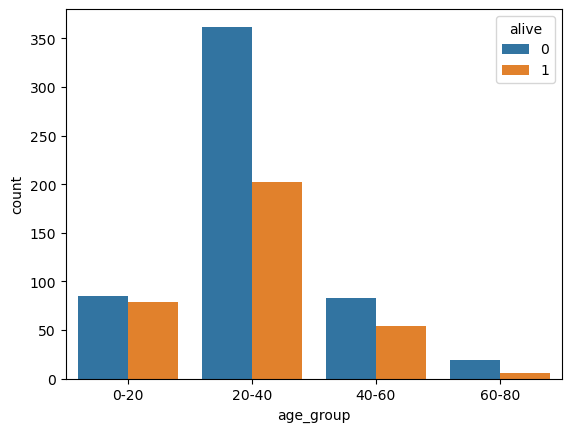

In [20]:
sns.countplot( x = 'age_group' , hue = 'alive' , data = df)

In [21]:
df.groupby('age_group')['alive'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_13588\3238152364.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['alive'].mean()


age_group
0-20     0.481707
20-40    0.358156
40-60    0.394161
60-80    0.240000
Name: alive, dtype: float64

In [30]:
df['sex'].value_counts(normalize=True)*100



sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

In [31]:
df['alive'].value_counts(normalize = True)*100

alive
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [34]:
pd.crosstab(df['sex'] , df['alive'],normalize='index')*100

alive,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


#1️⃣ normalize=False (default)

Sirf count deta hai (kitne log hain).

2️⃣ normalize=True

Ye poore table ka total nikalta hai
(81+233+468+109 = 891)
aur har cell ko total passengers se divide karta hai.

👉 Matlab ye overall percentage deta hai
— “poore Titanic ke 100% mein se kitne female bachi” etc.

3️⃣ normalize='index'

Yahi tera question hai 💡

Yahan “index” ka matlab row-wise hai (yani per “sex”).
Matlab ye har row ke total ko 1 (ya 100%) bana deta hai.
| alive  | no  | yes | total |
| ------ | --- | --- | ----- |
| female | 81  | 233 | 314   |
| male   | 468 | 109 | 577   |


| alive  | no              | yes             |
| ------ | --------------- | --------------- |
| female | 81/314 = 0.257  | 233/314 = 0.743 |
| male   | 468/577 = 0.811 | 109/577 = 0.189 |


<Axes: xlabel='sex', ylabel='class'>

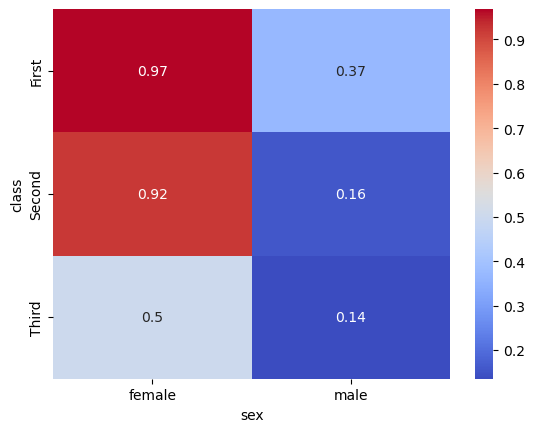

In [43]:
sns.heatmap(pd.crosstab(df['class'] , df['sex'] , values = df['alive'] , aggfunc = 'mean' ), annot=True , cmap ='coolwarm')


<Axes: xlabel='class', ylabel='age'>

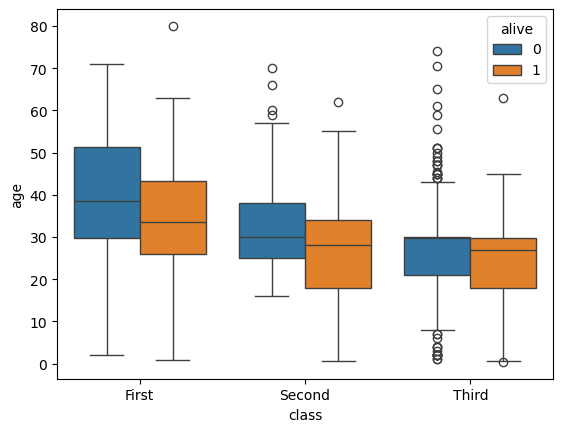

In [49]:
sns.boxplot(x=df['class'] , y=df['age'] , hue = df['alive'] ,data = df)

<Axes: xlabel='class', ylabel='age_group'>

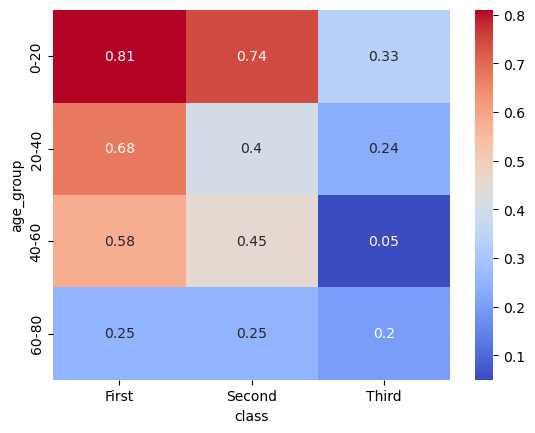

In [46]:
sns.heatmap(pd.crosstab(df['age_group'] , df['class'] , values = df['alive'] , aggfunc ='mean') , annot= True , cmap = 'coolwarm')